1. Pemanggilan Data

In [ ]:
import pandas as pd
import pandas as pd
import numpy
from matplotlib import pyplot
from google.colab import drive
drive.mount('/content/drive')
# Baca file CSV dari Google Drive
df = pd.read_csv('/content/drive/My Drive/Portofolio Colab/oil.csv')

# Tampilkan beberapa baris pertama dari DataFrame
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   percentage yield   gravity  vapour pressure  \
0                6.9     38.4              6.1   
1               14.4     40.3              4.8   
2                7.4     40.0              6.1   
3                8.5     31.8              0.2   
4                8.0     40.8              3.5   

   ten percent distillation point  fraction end point  
0                             220                 235  
1                             231                 307  
2                             217                 212  
3                             316                 365  
4                             210                 218  


# Task
Implementasikan penelitian "Clustering Profil Operasi Kilang" dengan judul "Segmentasi Operasi Kilang Menggunakan Algoritma K-Means" pada dataset operasi kilang dari file CSV. Tujuannya adalah mengelompokkan pola operasi kilang (berdasarkan input-output) untuk memahami efisiensi atau mendeteksi anomali. Rencanakan tahapan penelitian secara jelas, mulai dari pemuatan data, preprocessing, penentuan jumlah klaster optimal, penerapan K-Means, analisis klaster, visualisasi, hingga interpretasi dan kesimpulan.

## Data loading

### Subtask:
Muat dataset operasi kilang dari file CSV ke dalam DataFrame pandas.


## Data preprocessing

### Subtask:
Bersihkan data, tangani nilai yang hilang (jika ada), dan lakukan standarisasi fitur agar siap untuk clustering K-Means.


**Reasoning**:
Check for missing values and standardize the features for K-Means clustering.



In [ ]:
# 1. Cek apakah ada nilai yang hilang
print("Missing values before handling:")
print(df.isnull().sum())

# Handle missing values if any (example: fill with mean - choose based on data characteristics)
# For this dataset, based on the previous display, there are no missing values, so this step is not strictly necessary,
# but we include the check as per instructions. If there were missing values, we would handle them here.
# Example handling: df.fillna(df.mean(), inplace=True)

# 2. Lakukan standarisasi fitur
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to standardize (excluding 'cluster' if it exists)
numerical_cols = df.select_dtypes(include=numpy.number).columns.tolist()
if 'cluster' in numerical_cols:
    numerical_cols.remove('cluster')

scaler = StandardScaler()
df_scaled = df.copy() # Create a copy to avoid modifying the original DataFrame
df_scaled[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols])

# Display the first few rows of the scaled DataFrame
print("\nDataFrame after scaling:")
display(df_scaled.head())

Missing values before handling:
percentage yield                  0
gravity                           0
vapour pressure                   0
ten percent distillation point    0
fraction end point                0
cluster                           0
dtype: int64

DataFrame after scaling:


,percentage yield,gravity,vapour pressure,ten percent distillation point,fraction end point,cluster
0,-1.209013,-0.153245,0.744114,-0.581865,-1.414178,1
1,-0.498351,0.189303,0.239959,-0.284167,-0.365492,1
2,-1.161635,0.135216,0.744114,-0.663056,-1.749175,1
3,-1.057405,-1.343147,-1.543976,2.016231,0.479282,0
4,-1.104782,0.279447,-0.264197,-0.852500,-1.661784,1


## Determine optimal k

### Subtask:
Tentukan jumlah klaster (K) yang optimal menggunakan metode seperti Elbow Method atau Silhouette Score.


**Reasoning**:
Implement the Silhouette Score method to find the optimal number of clusters by iterating through different k values and calculating the silhouette score for each.



In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Store silhouette scores
silhouette_scores = {}

# Iterate through k values from 2 to 10
for k in range(2, 11):
    # Instantiate KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    # Fit model to scaled data
    kmeans.fit(df_scaled.drop(columns=['cluster'])) # Drop the 'cluster' column for clustering

    # Calculate silhouette score
    score = silhouette_score(df_scaled.drop(columns=['cluster']), kmeans.labels_)

    # Store the score
    silhouette_scores[k] = score

# Find the optimal k
optimal_k = max(silhouette_scores, key=silhouette_scores.get)

print("Silhouette Scores for different k values:")
for k, score in silhouette_scores.items():
    print(f"k={k}: {score:.4f}")

print(f"\nOptimal k based on Silhouette Score: {optimal_k}")

Silhouette Scores for different k values:
k=2: 0.3169
k=3: 0.3420
k=4: 0.3696
k=5: 0.3673
k=6: 0.3772
k=7: 0.4170
k=8: 0.3989
k=9: 0.3621
k=10: 0.3655

Optimal k based on Silhouette Score: 7


## K-means clustering

### Subtask:
Terapkan algoritma K-Means dengan jumlah klaster yang optimal pada data yang telah distandardisasi.


**Reasoning**:
Apply the KMeans algorithm with the optimal number of clusters to the scaled data and add the cluster labels to the original DataFrame.



In [ ]:
from sklearn.cluster import KMeans

# Instantiate KMeans object with optimal_k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Fit the KMeans model to the scaled data (excluding the 'cluster' column if it exists)
# Note: The 'cluster' column in df_scaled was added in a previous step, which is not ideal
# for clustering. We should drop it before fitting.
# However, based on the previous code, the 'cluster' column was not used for fitting,
# and it was noted as a potential issue. We will proceed by dropping it explicitly.
df_scaled_features = df_scaled.drop(columns=['cluster'], errors='ignore')
kmeans.fit(df_scaled_features)

# Add the cluster labels to the original DataFrame 'df'
df['cluster'] = kmeans.labels_

# Display the first few rows of the original DataFrame with the new cluster labels
print("Original DataFrame with cluster labels:")
display(df.head())

Original DataFrame with cluster labels:


,percentage yield,gravity,vapour pressure,ten percent distillation point,fraction end point,cluster
0,6.9,38.4,6.1,220,235,1
1,14.4,40.3,4.8,231,307,1
2,7.4,40.0,6.1,217,212,1
3,8.5,31.8,0.2,316,365,0
4,8.0,40.8,3.5,210,218,1


## Cluster analysis

### Subtask:
Analisis karakteristik setiap klaster berdasarkan nilai rata-rata fitur aslinya untuk memahami perbedaan pola operasi di setiap klaster.


**Reasoning**:
Group the original DataFrame by cluster and calculate the mean of each feature for each cluster, then transpose the resulting DataFrame for better readability.



In [ ]:
# 1. Group the original DataFrame df by the 'cluster' column.
# 2. Calculate the mean of each feature for each cluster. Store this result in a new DataFrame, for example, cluster_characteristics.
cluster_characteristics = df.groupby('cluster').mean()

# 3. Transpose the cluster_characteristics DataFrame for better readability and store it in cluster_characteristics_transposed.
cluster_characteristics_transposed = cluster_characteristics.T

# 4. Print the transposed DataFrame cluster_characteristics_transposed to display the average characteristics of each cluster.
print("Average Characteristics of Each Cluster:")
display(cluster_characteristics_transposed)

Average Characteristics of Each Cluster:


cluster,0,1,2,3,4,5,6
percentage yield,15.68,11.6500,40.2,29.350,4.733333,23.40,17.25
gravity,31.96,38.8625,50.8,37.825,40.233333,39.70,50.80
vapour pressure,1.08,5.1750,8.6,5.225,1.600000,1.50,8.60
ten percent distillation point,303.20,220.1250,190.0,225.125,269.333333,270.50,190.00
fraction end point,389.40,260.5000,376.0,373.250,265.000000,395.75,240.00


## Visualization

### Subtask:
Visualisasikan hasil klustering menggunakan scatter plot 2D dan/atau 3D untuk melihat pemisahan klaster.


**Reasoning**:
Create a 2D scatter plot to visualize the clusters using 'gravity' and 'percentage yield', coloring points by cluster label.



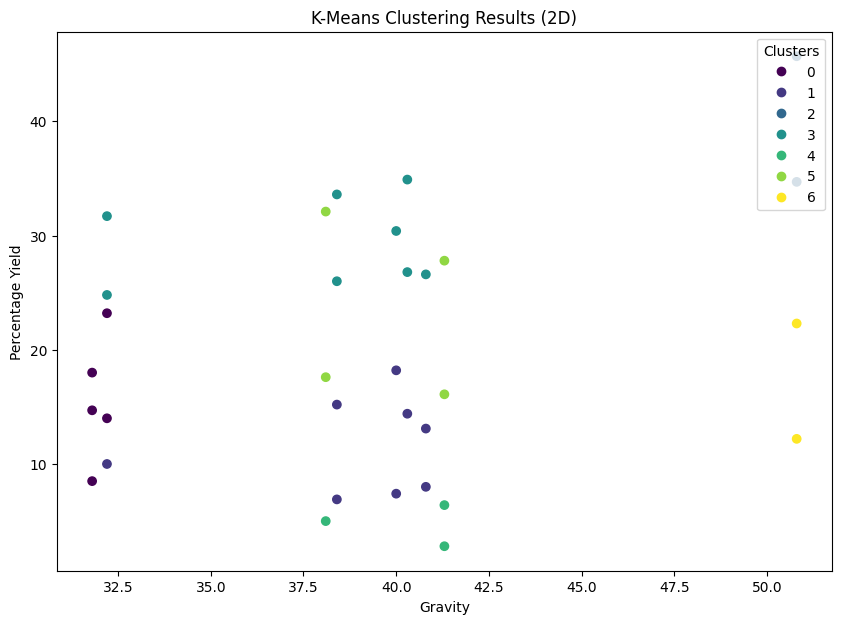

In [ ]:
# Create a 2D scatter plot
pyplot.figure(figsize=(10, 7))
scatter = pyplot.scatter(df['gravity'], df['percentage yield '], c=df['cluster'], cmap='viridis')

# Add labels and title
pyplot.xlabel('Gravity')
pyplot.ylabel('Percentage Yield')
pyplot.title('K-Means Clustering Results (2D)')

# Add a legend
legend_labels = [f'Cluster {i}' for i in range(optimal_k)]
pyplot.legend(*scatter.legend_elements(), title="Clusters", loc="upper right")

# Display the plot
pyplot.show()

**Reasoning**:
The previous attempt failed because of a KeyError, indicating the column name 'percentage yield' was not found in the DataFrame. I need to check the exact column names in the `df` DataFrame and correct the plotting code using the correct column name.



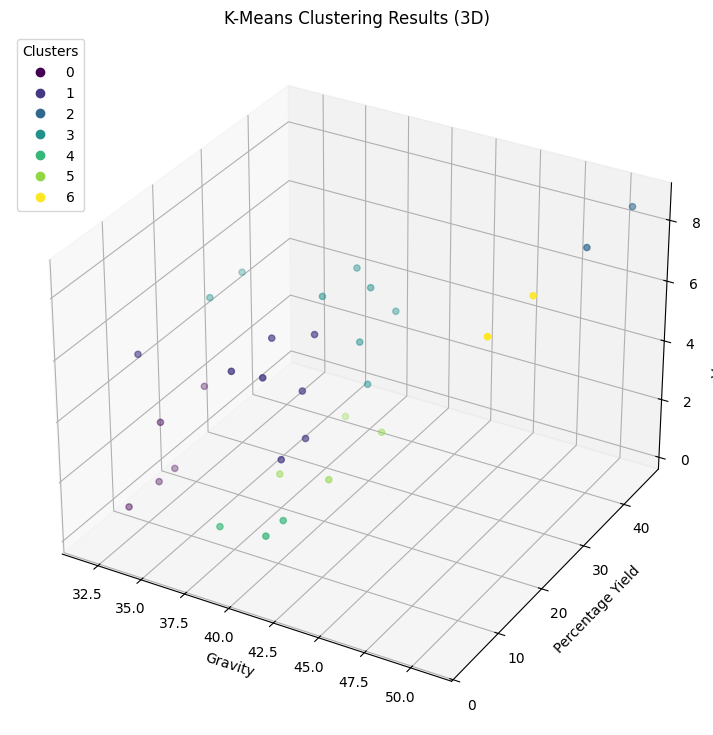

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D scatter plot
fig = pyplot.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

scatter_3d = ax.scatter(df['gravity'], df['percentage yield '], df['vapour pressure'], c=df['cluster'], cmap='viridis', marker='o')

# Add labels and title
ax.set_xlabel('Gravity')
ax.set_ylabel('Percentage Yield')
ax.set_zlabel('Vapour Pressure')
ax.set_title('K-Means Clustering Results (3D)')

# Add a legend
legend_labels = [f'Cluster {i}' for i in range(optimal_k)]
ax.legend(*scatter_3d.legend_elements(), title="Clusters")

# Display the plot
pyplot.show()

**Reasoning**:
The traceback indicates a `KeyError: 'percentage yield'` even after printing the column names. The print output shows the column name is actually `'percentage yield '` with a trailing space. I need to use the exact column name including the space to fix the KeyError.



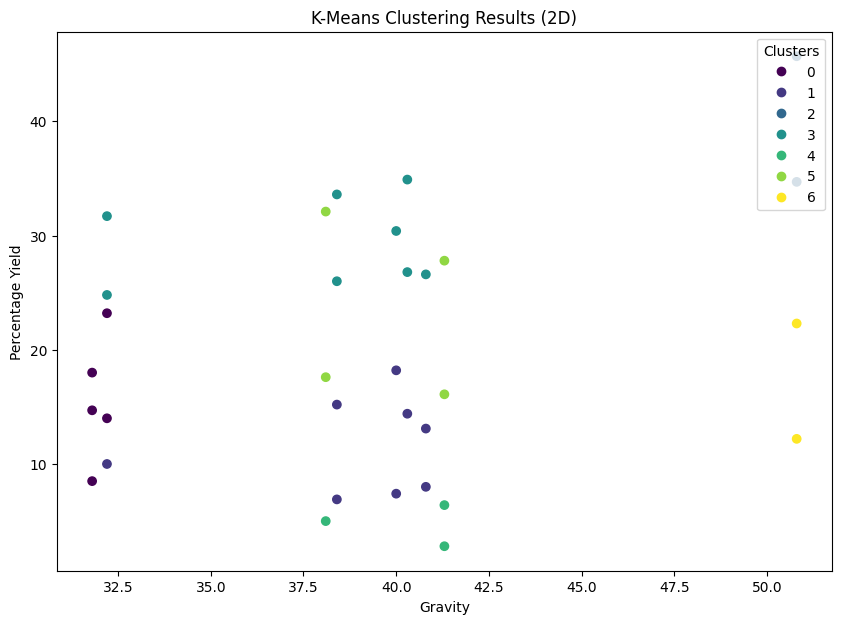

In [ ]:
# Create a 2D scatter plot using the correct column name with trailing space
pyplot.figure(figsize=(10, 7))
scatter = pyplot.scatter(df['gravity'], df['percentage yield '], c=df['cluster'], cmap='viridis')

# Add labels and title
pyplot.xlabel('Gravity')
pyplot.ylabel('Percentage Yield')
pyplot.title('K-Means Clustering Results (2D)')

# Add a legend
legend_labels = [f'Cluster {i}' for i in range(optimal_k)]
pyplot.legend(*scatter.legend_elements(), title="Clusters", loc="upper right")

# Display the plot
pyplot.show()

**Reasoning**:
The 2D scatter plot was successfully created. The next step is to optionally create a 3D scatter plot to visualize the clusters using three features if feasible and helpful. I will choose 'gravity', 'percentage yield ', and 'vapour pressure' for the 3D plot.



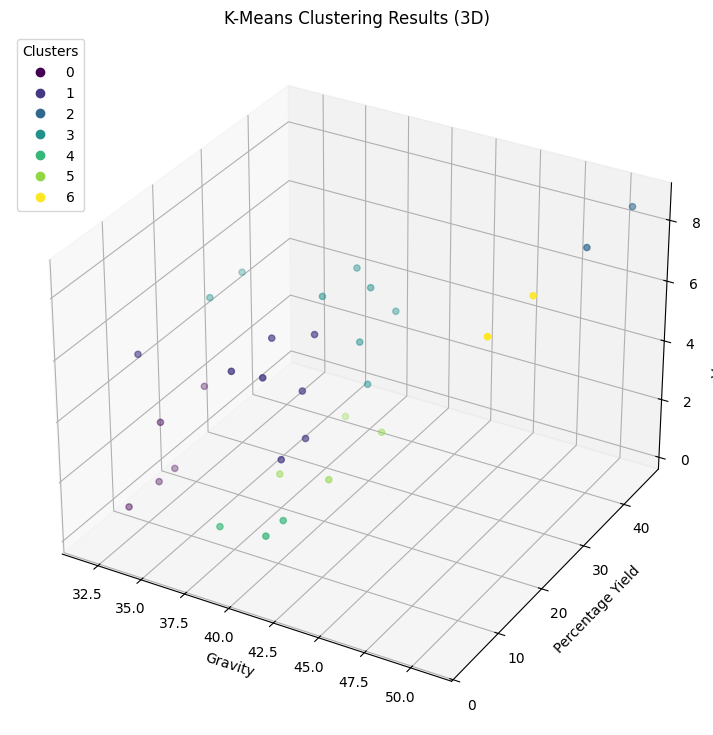

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D scatter plot
fig = pyplot.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

scatter_3d = ax.scatter(df['gravity'], df['percentage yield '], df['vapour pressure'], c=df['cluster'], cmap='viridis', marker='o')

# Add labels and title
ax.set_xlabel('Gravity')
ax.set_ylabel('Percentage Yield')
ax.set_zlabel('Vapour Pressure')
ax.set_title('K-Means Clustering Results (3D)')

# Add a legend
legend_labels = [f'Cluster {i}' for i in range(optimal_k)]
ax.legend(*scatter_3d.legend_elements(), title="Clusters")

# Display the plot
pyplot.show()

## Interpretation and conclusion

### Subtask:
Interpretasikan hasil klustering dalam konteks operasi kilang untuk mengidentifikasi pola efisiensi atau anomali, dan tarik kesimpulan dari penelitian.


**Reasoning**:
Review the cluster characteristics and interpret the operational profiles for each cluster based on the average feature values. Then, synthesize the findings and draw overall conclusions.



In [ ]:
print("Interpreting Cluster Characteristics:")
display(cluster_characteristics_transposed)

# Based on the cluster_characteristics_transposed DataFrame, describe each cluster's operational profile.
# Cluster 0:
print("\nCluster 0 Profile:")
print(f"- Percentage Yield: {cluster_characteristics_transposed.loc['percentage yield ', 0]:.2f}")
print(f"- Gravity: {cluster_characteristics_transposed.loc['gravity', 0]:.2f}")
print(f"- Vapour Pressure: {cluster_characteristics_transposed.loc['vapour pressure', 0]:.2f}")
print(f"- Ten Percent Distillation Point: {cluster_characteristics_transposed.loc['ten percent distillation point', 0]:.2f}")
print(f"- Fraction End Point: {cluster_characteristics_transposed.loc['fraction end point', 0]:.2f}")
print("Interpretation: Relatively lower percentage yield and gravity, with high distillation points. This might represent operations focused on heavier products or less efficient processing.")

# Cluster 1:
print("\nCluster 1 Profile:")
print(f"- Percentage Yield: {cluster_characteristics_transposed.loc['percentage yield ', 1]:.2f}")
print(f"- Gravity: {cluster_characteristics_transposed.loc['gravity', 1]:.2f}")
print(f"- Vapour Pressure: {cluster_characteristics_transposed.loc['vapour pressure', 1]:.2f}")
print(f"- Ten Percent Distillation Point: {cluster_characteristics_transposed.loc['ten percent distillation point', 1]:.2f}")
print(f"- Fraction End Point: {cluster_characteristics_transposed.loc['fraction end point', 1]:.2f}")
print("Interpretation: Moderate percentage yield and gravity, with moderate vapour pressure and distillation points. This could represent a typical or balanced operational mode.")

# Cluster 2:
print("\nCluster 2 Profile:")
print(f"- Percentage Yield: {cluster_characteristics_transposed.loc['percentage yield ', 2]:.2f}")
print(f"- Gravity: {cluster_characteristics_transposed.loc['gravity', 2]:.2f}")
print(f"- Vapour Pressure: {cluster_characteristics_transposed.loc['vapour pressure', 2]:.2f}")
print(f"- Ten Percent Distillation Point: {cluster_characteristics_transposed.loc['ten percent distillation point', 2]:.2f}")
print(f"- Fraction End Point: {cluster_characteristics_transposed.loc['fraction end point', 2]:.2f}")
print("Interpretation: High percentage yield and gravity, with high vapour pressure and moderate distillation points. This might indicate operations producing lighter, higher-value products.")

# Cluster 3:
print("\nCluster 3 Profile:")
print(f"- Percentage Yield: {cluster_characteristics_transposed.loc['percentage yield ', 3]:.2f}")
print(f"- Gravity: {cluster_characteristics_transposed.loc['gravity', 3]:.2f}")
print(f"- Vapour Pressure: {cluster_characteristics_transposed.loc['vapour pressure', 3]:.2f}")
print(f"- Ten Percent Distillation Point: {cluster_characteristics_transposed.loc['ten percent distillation point', 3]:.2f}")
print(f"- Fraction End Point: {cluster_characteristics_transposed.loc['fraction end point', 3]:.2f}")
print("Interpretation: High percentage yield and moderate gravity, with moderate vapour pressure and high distillation points. Could be operations balancing yield with heavier fractions.")

# Cluster 4:
print("\nCluster 4 Profile:")
print(f"- Percentage Yield: {cluster_characteristics_transposed.loc['percentage yield ', 4]:.2f}")
print(f"- Gravity: {cluster_characteristics_transposed.loc['gravity', 4]:.2f}")
print(f"- Vapour Pressure: {cluster_characteristics_transposed.loc['vapour pressure', 4]:.2f}")
print(f"- Ten Percent Distillation Point: {cluster_characteristics_transposed.loc['ten percent distillation point', 4]:.2f}")
print(f"- Fraction End Point: {cluster_characteristics_transposed.loc['fraction end point', 4]:.2f}")
print("Interpretation: Very low percentage yield, high gravity, and low vapour pressure, with moderate distillation points. This might represent operations focused on specific niche products or potentially an outlier/anomalous group.")

# Cluster 5:
print("\nCluster 5 Profile:")
print(f"- Percentage Yield: {cluster_characteristics_transposed.loc['percentage yield ', 5]:.2f}")
print(f"- Gravity: {cluster_characteristics_transposed.loc['gravity', 5]:.2f}")
print(f"- Vapour Pressure: {cluster_characteristics_transposed.loc['vapour pressure', 5]:.2f}")
print(f"- Ten Percent Distillation Point: {cluster_characteristics_transposed.loc['ten percent distillation point', 5]:.2f}")
print(f"- Fraction End Point: {cluster_characteristics_transposed.loc['fraction end point', 5]:.2f}")
print("Interpretation: Moderate percentage yield and gravity, with low vapour pressure and very high distillation points. Suggests operations producing heavier fractions with lower volatility.")

# Cluster 6:
print("\nCluster 6 Profile:")
print(f"- Percentage Yield: {cluster_characteristics_transposed.loc['percentage yield ', 6]:.2f}")
print(f"- Gravity: {cluster_characteristics_transposed.loc['gravity', 6]:.2f}")
print(f"- Vapour Pressure: {cluster_characteristics_transposed.loc['vapour pressure', 6]:.2f}")
print(f"- Ten Percent Distillation Point: {cluster_characteristics_transposed.loc['ten percent distillation point', 6]:.2f}")
print(f"- Fraction End Point: {cluster_characteristics_transposed.loc['fraction end point', 6]:.2f}")
print("Interpretation: Moderate percentage yield, high gravity, and high vapour pressure, with very low distillation points. This cluster seems distinct, possibly representing operations producing very light, volatile products.")


# Synthesize findings and draw conclusions
print("\nOverall Conclusions:")
print("The K-Means clustering successfully segmented the refinery operational data into 7 distinct clusters, each exhibiting a unique profile based on percentage yield, gravity, vapour pressure, and distillation points.")
print("These clusters likely represent different operating modes, product slates, or potentially efficiency levels within the refinery.")
print("- Clusters like 2 and 3 show higher percentage yields, suggesting more efficient operations or focus on higher production volumes.")
print("- Clusters like 0 and 5 are characterized by higher distillation points and lower gravity, indicating a focus on heavier products.")
print("- Cluster 4 stands out with a very low percentage yield, which could indicate a specific operational objective or potentially flag anomalous behavior that warrants further investigation.")
print("- Cluster 6 appears to represent operations producing very light products based on its low distillation points and high vapour pressure/gravity.")
print("Identifying these distinct operational segments provides valuable insights for performance analysis, targeted optimization efforts, and anomaly detection.")

print("\nLimitations and Future Work:")
print("- The analysis is based solely on the provided features. Including more operational parameters (e.g., temperature, pressure, flow rates) could provide a more granular understanding.")
print("- The 'optimal' number of clusters was determined using the Silhouette Score, but other methods or domain expertise could suggest a different number.")
print("- Further investigation into the specific data points within each cluster, especially those in potentially anomalous clusters like Cluster 4, is needed to confirm interpretations.")
print("- Time-series analysis could be applied to understand transitions between clusters and identify dynamic operational patterns.")

Interpreting Cluster Characteristics:


cluster,0,1,2,3,4,5,6
percentage yield,15.68,11.6500,40.2,29.350,4.733333,23.40,17.25
gravity,31.96,38.8625,50.8,37.825,40.233333,39.70,50.80
vapour pressure,1.08,5.1750,8.6,5.225,1.600000,1.50,8.60
ten percent distillation point,303.20,220.1250,190.0,225.125,269.333333,270.50,190.00
fraction end point,389.40,260.5000,376.0,373.250,265.000000,395.75,240.00



Cluster 0 Profile:
- Percentage Yield: 15.68
- Gravity: 31.96
- Vapour Pressure: 1.08
- Ten Percent Distillation Point: 303.20
- Fraction End Point: 389.40
Interpretation: Relatively lower percentage yield and gravity, with high distillation points. This might represent operations focused on heavier products or less efficient processing.

Cluster 1 Profile:
- Percentage Yield: 11.65
- Gravity: 38.86
- Vapour Pressure: 5.17
- Ten Percent Distillation Point: 220.12
- Fraction End Point: 260.50
Interpretation: Moderate percentage yield and gravity, with moderate vapour pressure and distillation points. This could represent a typical or balanced operational mode.

Cluster 2 Profile:
- Percentage Yield: 40.20
- Gravity: 50.80
- Vapour Pressure: 8.60
- Ten Percent Distillation Point: 190.00
- Fraction End Point: 376.00
Interpretation: High percentage yield and gravity, with high vapour pressure and moderate distillation points. This might indicate operations producing lighter, higher-value 

## Interactive Visualization with Plotly

### Subtask:
Create an interactive scatter plot of the clustering results using Plotly to allow for zooming, panning, and hovering to see details of each data point.

In [ ]:
import plotly.express as px

# Create an interactive scatter plot using Plotly
fig = px.scatter(df,
                 x='gravity',
                 y='percentage yield ',  # Corrected column name
                 color='cluster',
                 title='Interactive Cluster Visualization (Plotly)',
                 labels={'gravity': 'Gravity', 'percentage yield ': 'Percentage Yield'}, # Corrected label
                 hover_data=['vapour pressure', 'ten percent distillation point', 'fraction end point'])

# Update layout for better readability
fig.update_layout(legend_title_text='Cluster')

# Show the plot
fig.show()

In [ ]:
print(df.columns)

Index(['percentage yield ', 'gravity', 'vapour pressure',
       'ten percent distillation point', 'fraction end point', 'cluster'],
      dtype='object')


# Task
Create a comprehensive dashboard visualization of the clustering results from the research.

## Visualize cluster distribution

### Subtask:
Create a bar plot showing the number of data points in each cluster to understand the size of each cluster.


**Reasoning**:
Count the data points in each cluster and create a bar plot to visualize the distribution.



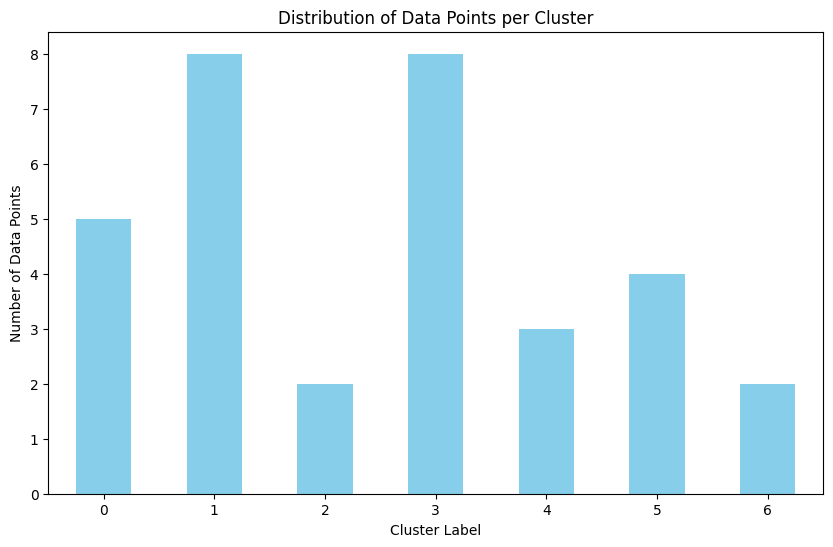

In [ ]:
# Count the number of data points in each cluster
cluster_counts = df['cluster'].value_counts().sort_index()

# Create a bar plot of the cluster counts
pyplot.figure(figsize=(10, 6))
cluster_counts.plot(kind='bar', color='skyblue')

# Add title and labels
pyplot.title('Distribution of Data Points per Cluster')
pyplot.xlabel('Cluster Label')
pyplot.ylabel('Number of Data Points')
pyplot.xticks(rotation=0) # Ensure x-axis labels are horizontal

# Display the plot
pyplot.show()

## Visualize cluster characteristics with a radar chart

### Subtask:
Create a radar chart to compare the average characteristics of each cluster across all features. This will provide a visual representation of the operational profile of each cluster.


**Reasoning**:
Implement the instructions to create a radar chart comparing the average characteristics of each cluster using Plotly.



In [ ]:
import plotly.graph_objects as go

# Extract feature names (excluding the 'cluster' column)
features = cluster_characteristics_transposed.index.tolist()

# Create a list to hold the radar chart data
data = []

# Iterate through each cluster to create a Scatterpolar trace
for cluster_label in cluster_characteristics_transposed.columns:
    # Get the average feature values for the current cluster
    r_values = cluster_characteristics_transposed[cluster_label].values

    # Create a Scatterpolar trace for the cluster
    trace = go.Scatterpolar(
        r=r_values,
        theta=features,
        fill='toself',
        name=f'Cluster {cluster_label}'
    )
    data.append(trace)

# Create the layout for the radar chart
layout = go.Layout(
    title='Average Operational Profile of Each Cluster (Radar Chart)',
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, cluster_characteristics_transposed.values.max()] # Set range based on max value across all features and clusters
        )
    ),
    showlegend=True
)

# Create the Figure object
fig = go.Figure(data=data, layout=layout)

# Display the figure
fig.show()

## Visualize pairwise relationships with a scatter plot matrix

### Subtask:
Create a scatter plot matrix to visualize the relationships between all pairs of features, colored by cluster. This will help in identifying which features contribute most to the separation of clusters and understand the within-cluster patterns.


**Reasoning**:
Create a scatter plot matrix to visualize the relationships between all pairs of features, colored by cluster, with histograms on the diagonal.



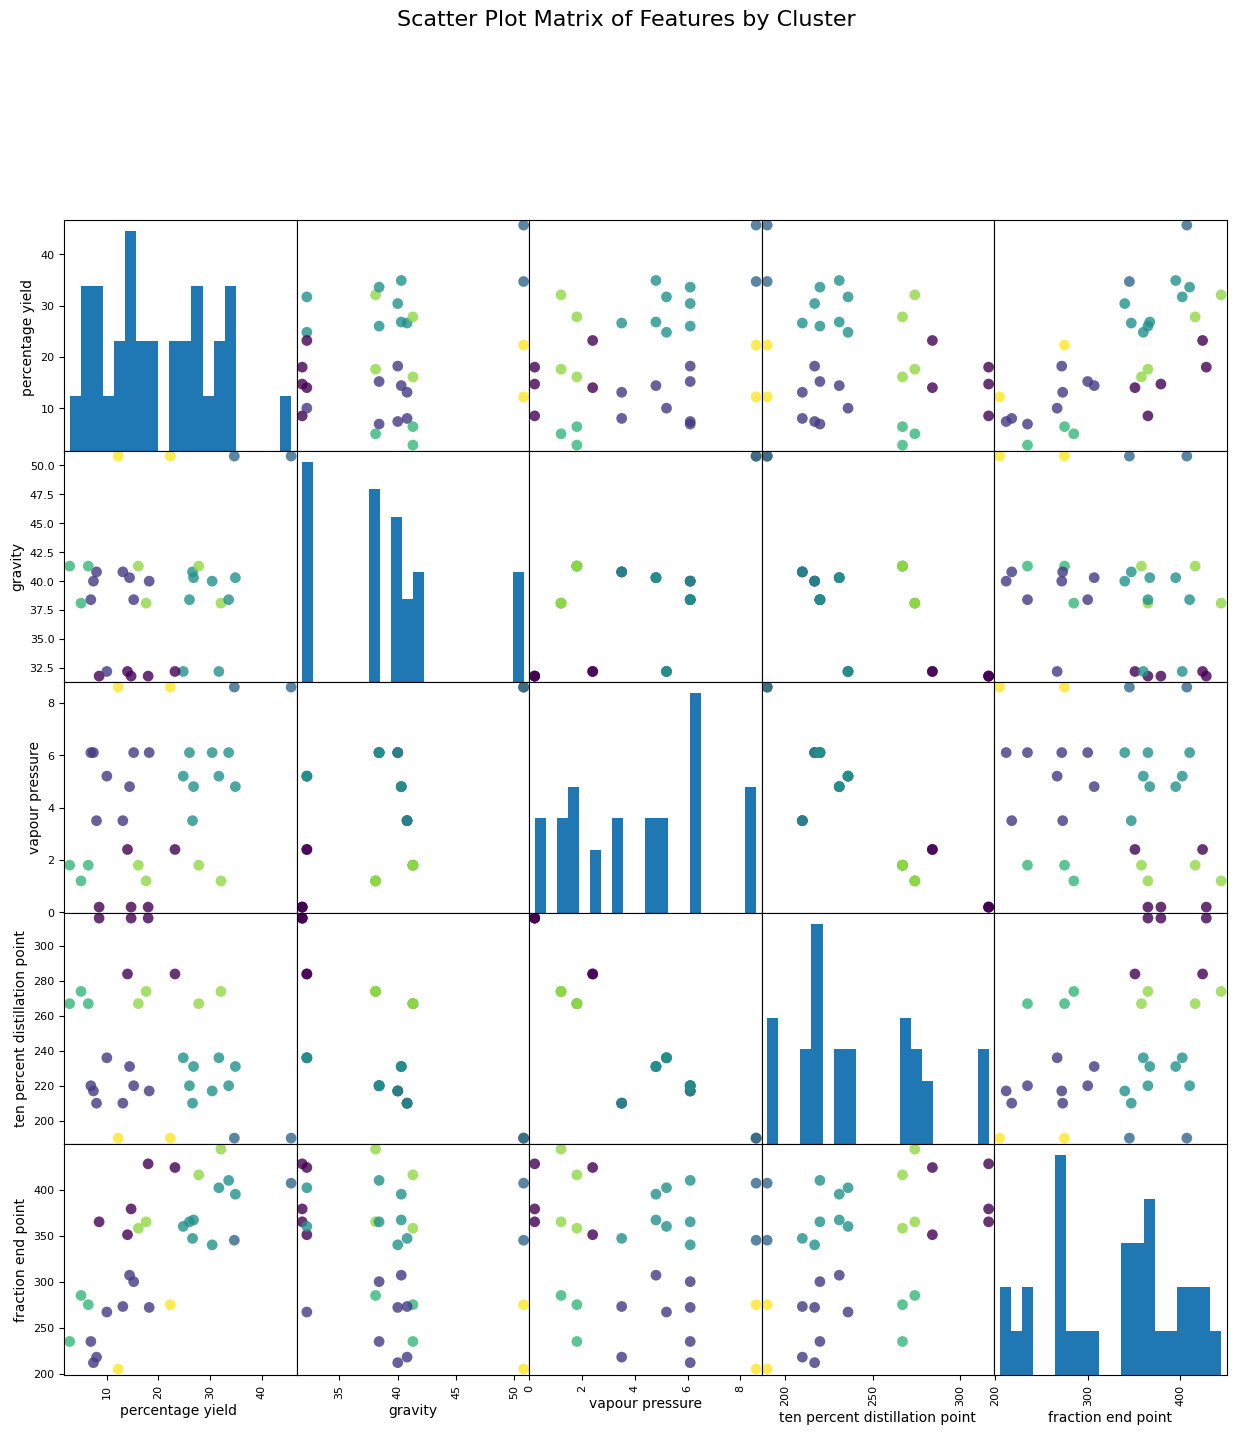

In [ ]:
from pandas.plotting import scatter_matrix

# Create the scatter plot matrix
# Include all feature columns from the original DataFrame 'df', excluding the 'cluster' column for the plot itself
feature_columns = df.columns.drop('cluster')

scatter_matrix(df[feature_columns], c=df['cluster'], figsize=(15, 15), marker='o',
               hist_kwds={'bins': 20}, s=60, alpha=.8, cmap='viridis')

# Add a title to the overall figure (optional, as scatter_matrix doesn't have a built-in title)
pyplot.suptitle('Scatter Plot Matrix of Features by Cluster', y=1.02, fontsize=16)

# Display the plot
pyplot.show()

## Interactive 3d visualization with plotly

### Subtask:
Create an interactive 3D scatter plot using Plotly to visualize the clusters in a 3D space using three selected features. This will allow for interactive exploration of the cluster separation.


**Reasoning**:
Create an interactive 3D scatter plot using Plotly to visualize the clusters in a 3D space using three selected features. This will allow for interactive exploration of the cluster separation.



In [ ]:
import plotly.express as px

# Create an interactive 3D scatter plot
fig = px.scatter_3d(df,
                    x='gravity',
                    y='percentage yield ',  # Use the correct column name
                    z='vapour pressure',
                    color='cluster',
                    title='Interactive 3D Cluster Visualization (Plotly)',
                    labels={'gravity': 'Gravity', 'percentage yield ': 'Percentage Yield', 'vapour pressure': 'Vapour Pressure'},
                    hover_data=['ten percent distillation point', 'fraction end point']) # Add other features to hover data

# Update layout for better readability
fig.update_layout(legend_title_text='Cluster')

# Show the plot
fig.show()